# 🚗 Predicting Car Prices with Machine Learning

Welcome, data explorers! 👩‍💻👨‍💻🚀

Imagine you're browsing through a car dealership’s website and wondering — *"Why is this car more expensive than that one?"* 🤔  
Well, today **you’re the data scientist behind the scenes**, building a model that helps answer exactly that.

In this case study, you and your team will work on an **end-to-end machine learning project** to **predict car prices** based on various features like the model, year, mileage, fuel type, and more. We'll be using a real-world dataset from the automotive market — noisy, messy, and full of patterns waiting to be discovered. 🧠📊

You'll walk through the full ML pipeline:  
- Cleaning and preprocessing the data 🧹  
- Exploring the hidden relationships 🔍  
- Building and tuning regression models 🛠️  
- Evaluating how well your model performs 📈  
- And maybe... deploying it? (ambitious, but hey — dream big!)

By the end of this notebook, you’ll have built a model that can **predict the price of a car**, and more importantly, you'll understand how to tackle real-world machine learning problems from scratch.

Let’s rev up our engines and start predicting! 🏁💥


#### First, let's take a look at our dataset

In [3]:

import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,audi


#### 2. Explore the Dataset (EDA - Exploratory Data Analysis)
Understand the structure and content:

Shape of the dataset

Data types

Missing values

Statistical summary

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  int64  
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 5.5 MB


In [5]:
# Summary statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16579.987506,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.218027,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,99.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


#### Let's get some insights

🔧 Year: 
- Mean year of cars is ~2017, with a range from 1996 to 2020.
- 75% of the cars are from 2016 or newer, indicating the dataset is mostly composed of recent vehicles.
- The standard deviation (~2.1 years) shows low year variability — mostly modern cars.

💰 Price
- Car prices range from as low as £495 to £145,000 — this is a huge spread, likely including luxury and budget models.
- The average price is around £16,580, with a median of £14,495, suggesting a right-skewed distribution (some very expensive outliers).

🛣️ Mileage
- Mileage spans from 0 to 323,000 miles — a massive range.
- Median mileage is around 17,531, and the mean is 23,176, again showing a right-skewed distribution (many high-mileage cars).

💸 Tax
- Tax ranges from £0 to £580, with a median of £145, which likely reflects common tax bands.
- Mean tax is ~£117, and 75% of cars fall below £145 — outliers should be reviewed here as well.

⛽ MPG (Miles per Gallon)
- Extremely wide range from 0.3 to 470.8 MPG — the upper value is almost certainly an anomaly or data entry error (possibly electric vehicles with an equivalent mpg).
- Median of 55.4 MPG, and average of ~55.85, suggesting mostly fuel-efficient vehicles.

🔧 Engine Size
- Engine sizes range from 0.0 to 6.6 liters, with median = 1.6L, which aligns with common car engines.
- Some 0.0 engine sizes might indicate missing or erroneous values.
- Values above 4.0L likely belong to high-performance/luxury cars.

#### Do we have missing values??

In [6]:
# Check for missing values
df.isnull().sum()
# df.fillna(0).count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

###### Handling Missing Values – Quick Decision Guide

---

###### 1) Identify Feature Type
- **Categorical (`make`, `model`)** → Mode, `"Unknown"`, or predictive modeling  
- **Numerical (`price`, `mileage`, `engineSize`)** → Mean/Median, group-wise stats, or regression/KNN  
- **Ordinal (e.g., condition 1–5)** → Median or interpolation  

---

###### 2) Check Missingness Percentage
- **<5%** → Simple imputation (mean/median/mode)  
- **5–30%** → Group-wise or model-based imputation  
- **>30%** → Consider dropping or advanced methods  

---

###### 3) Determine Missingness Mechanism
- **MCAR** (*Completely Random – e.g., data entry errors*) → Mean/median (num), Mode (cat)  
- **MAR** (*Depends on other features – e.g., mileage missing in new cars*) → Group-wise, Regression, or KNN  
- **MNAR** (*Depends on the value itself – e.g., high-priced cars hiding price*) → Keep as `NaN`, or add `"missing"` flag  

---

###### 4) Check Data Ordering
- **Sequential/Time-series** → FFILL/BFILL **within groups only**  
- **Unordered (typical listings)** → Prefer statistical or model-based methods; **avoid FFILL/BFILL**  

---

###### 5) Quick Reference Table

| Situation                | Recommended Method                          |
|---------------------------|---------------------------------------------|
| Categorical, low missing  | Mode or `"Unknown"` category                |
| Numerical, MCAR           | Mean or median                              |
| Numerical, MAR            | Group-wise median/mean, KNN, or regression  |
| Numerical, MNAR           | Keep as `NaN` or add `"missing"` flag       |
| Sequential data           | FFILL/BFILL within same group only          |

---

###### 6) Best Practices
✔ Analyze missingness before imputing  
✔ Group by similar characteristics (`make`, `model`) when filling  
✔ Never propagate values across unrelated groups  
✔ Test model performance **with & without** imputation  

---


#### Load dataset again to see it here

In [7]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai


##### Ok, now take am moment to inspect the data closely. Which is the target variable? -in our case, the price. What car brands do we have, models, what fuel type corresponds to what model, and so on. 
##### The best way to do this is of course, using visual types of plots! 

📊 1. Distribution of Car Prices
Shows price skewness and outliers.

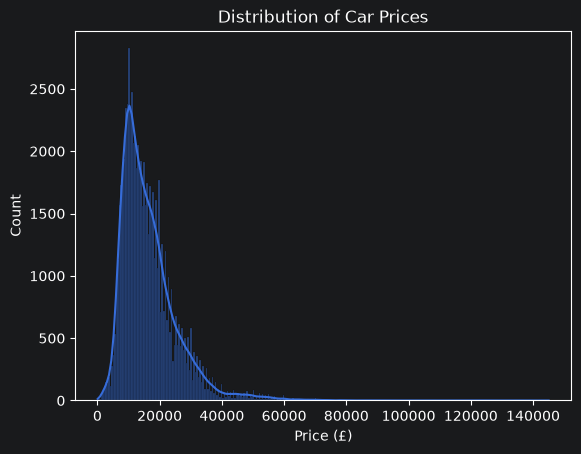

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins="auto", kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()



####  TODO: Write some conclusions 
#### This is a right skew - most data points are concentrated the left side
#### - Most cars are priced at the lower end
#### - A long tail extends to very expensive cars (£60,000–£140,000), but these are rare
#### - The mode (peak) is around £10,000–£15,000, meaning this is the most common price range
#### - Cars priced above ~£60,000 are rare outliers; they may need separate analysis if predicting or modeling prices
##### Concluzii: cum este de asteptat, datasetul pune in evidenta o situatie reala adica faptul ca precum pe strada si in dataset exista mult mai multe masini "mid-range" chiar low-range si masinile foarte scumpe sunt o exceptie. In dataset exista si masini cu preturi foarte mici de ex audi A1 care are pretul 99 , acesti outlieri o sa influenezeze modelul, asa ca o sa fie nevoie de o analiza mai amanuntita a lor si poate chiar eliminarea lor din dataset. Exista si outlieri de preturi foarte mari care practic sunt normale pentru anumite modele de masini totusi analiza lor ar trebui sa fie facuta separat pentru ca avand in vedere ca sunt putine si folosind un model de regresie, modelul o sa fie influentat de acesti outlieri si o sa prezica gresit preturile pentru masinile mid-range.

🧼 2. Boxplot of Price by Transmission Type
Compare prices across automatic vs manual cars.

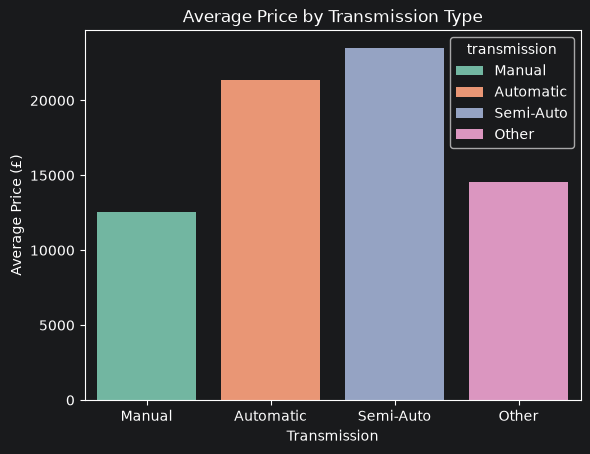

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use 'hue' to apply the palette per category
sns.barplot(
    x='transmission',
    y='price',
    data=df,
    hue='transmission',
    palette='Set2',
    errorbar=None,              
    legend=True             
)

plt.title('Average Price by Transmission Type')
plt.ylabel('Average Price (£)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.show()

####  TODO: Write some conclusions 
#### highest average price - Semi-Auto cars costs around 24k £
## Concluzii
##### pe baza diagrammei de mai sus se poate observa faptul ca in functie de tipul de transmisie pretul difera astfel se dedeuce corelatia dintre tipul de transmisie si pretul mediu al masinilor, astfel incat masinile cu transmisie semi-automata sunt cele mai scumpe (~20+ k), urmate de cele cu transmisie automata (tot peste 20 de k dar mai jos decat cele semiautomatice), iar cele cu transmisie manuala sunt cele mai ieftine (intre 10 si 15), categoria other este intre pretul celor manuale si celor automate .



⛽ 3. Boxplot of Price by Fuel Type
Helps assess how fuel type affects car pricing.

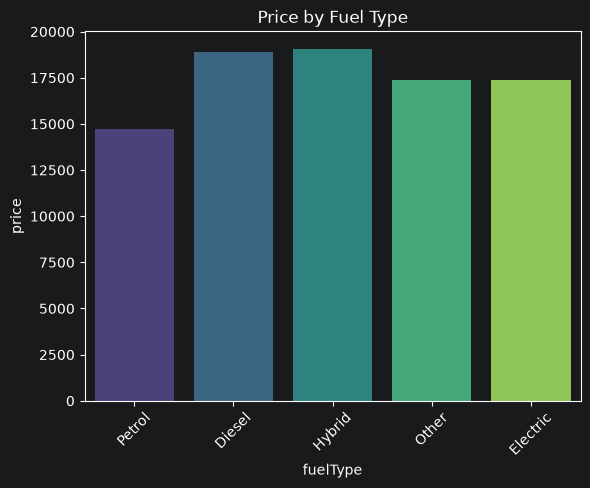

In [10]:


sns.barplot(x='fuelType', y='price', data=df, hue='fuelType',         
    palette='viridis',
    errorbar=None,              
    legend=False )
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions 
#### - Petrol-fueled cars are the cheapest
#### - Hybrid-fueled cars have the highest prices

## Concluzii
##### la fel ca si in diagrama anterioara in aceasta diagrama se pune in evidenta corelatie dintre tipul de combustibil si pret.Astfel masinile hibrid sunt cele mai scumpe, urmate de cele diesel, iar cele pe benzina sunt cele mai ieftine. Tipul other si electric sunt aprox egale ca pret ceea ce poate creea confuzii in clasificarea masinilor electrice, la fel intre diesel si hibrid, dar aici diferenta de pret este mai mare astfel va fi mai usor de facut diferentierea dintre cele doua.

🏷️ 4. Average Price per Car Make
Top 15 brands only for readability.


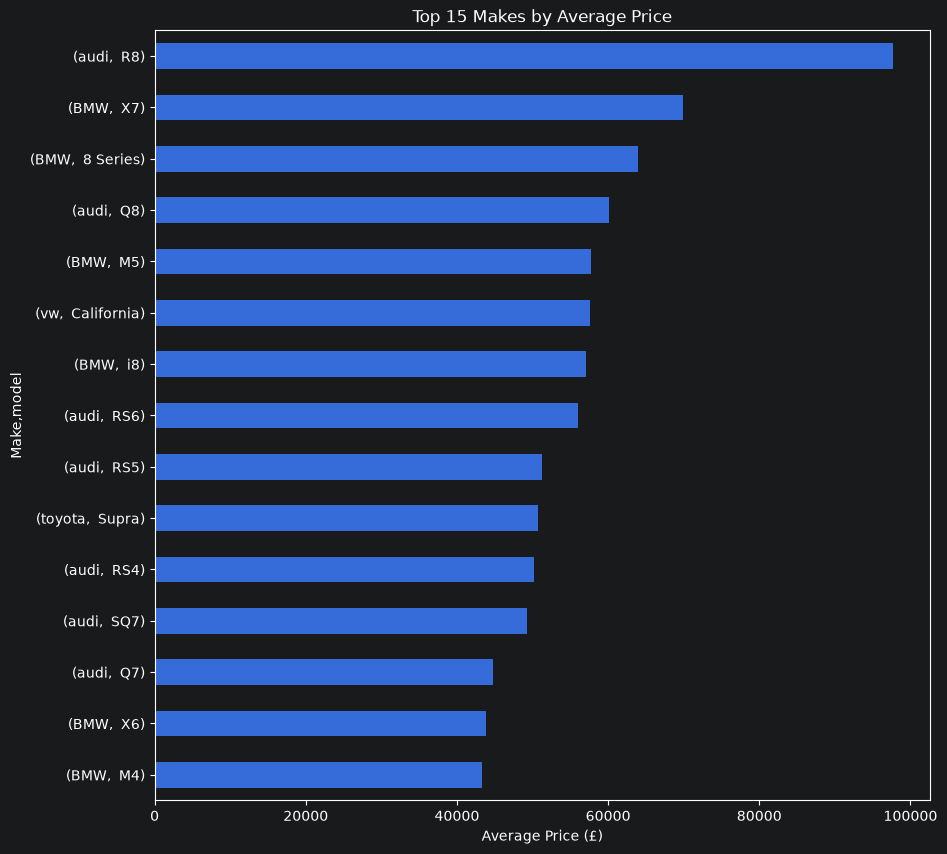

In [11]:
avg_price_by_make = df.groupby(['Make', 'model'])['price'].mean().sort_values(ascending=False).head(15)
avg_price_by_make.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Average Price (£)')
plt.title('Top 15 Makes by Average Price')
plt.gca().invert_yaxis()
plt.show()

####  TODO: Write some conclusions 
#### - Audi and BMW have the highest average prices
#### - Ford has the lowest average price

---
#### Switching to models we can see that the most expensive model is audi R8

## Concluzii
##### In diagrama prezentata se poate observa o corelatie mai aprofundata intre marca si pret , astfel incat masinile din marcile BMW si Audi domina din punct de vedere al pretului, totusi in aceasta deigrama se observa atat masini vw cat si toyota care sunt mai scumpe decat unele modele de audi si bmw ceea pune in evindenta si ponderea modelului in pretul masinii, ca ex vw california costa mai mult decat unele audi uri sau bmw uri , la fel si in cazul toyotei supra care costa mai mult decat unele modele de audi si bmw. Astfel se poate observa ca pretul unei masini nu este influentat doar de marca ci si de modelul acesteia.

📈 5. Scatterplot of Mileage vs. Price
See depreciation pattern as mileage increases.

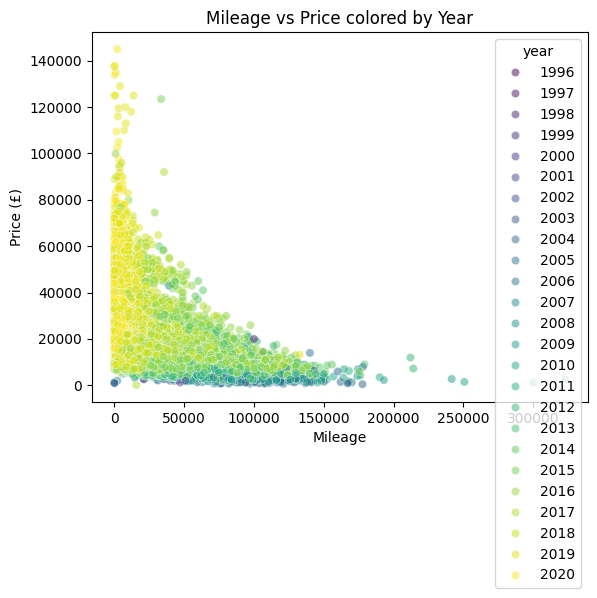

In [37]:
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, hue='year', palette='viridis', legend='full')
plt.title('Mileage vs Price colored by Year')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

####  TODO: Write some conclusions 
#### - Assigning a variable to hue map its levels to the color of the plots
#### - hue = year different colors for each year
#### - Newest cars (2018-2020) have low mileage and high prices 
#### - As the cars get older they increase in mileage, things that justify the low price
#### - High density of low priced cars
#### - Outliers: 
####      - new cars (expensive, low mileage)
####      - mid year cars (cheap, high mileage)

## Concluzii
##### In diagrama de mai sus primul lucru care iese in evidenta este pattern-ul dintre milage si pret , astfel se poate observa ca masinile cu putini km , in principal cele noi au preturi mai mari astfel se pune in evidenta corelatia dintre milage si pret , in diagrama se evidentiaza si corelartia dintre an si milage , in principiu masinile noi au putini km iar cele mai vechi au mai multi , astfel cu cat este mai veche masina cu atat are mai multi km si implicit si pretul este mai mic. Totusi in diagrama se observa si o densitate mai mare a masinilor low-range sau mid-range ca pret ceea ce pune in evidenta faptul ca in dataset exista mai multe masini ieftine decat scumpe. In diagrama se observa si outlieri, astfel masinile noi cu putini km au preturi mari iar masinile mid-year cu multi km au preturi mici. !!! de mai continuat!!


📅 6. Price vs Year
Understand how newer cars are priced.

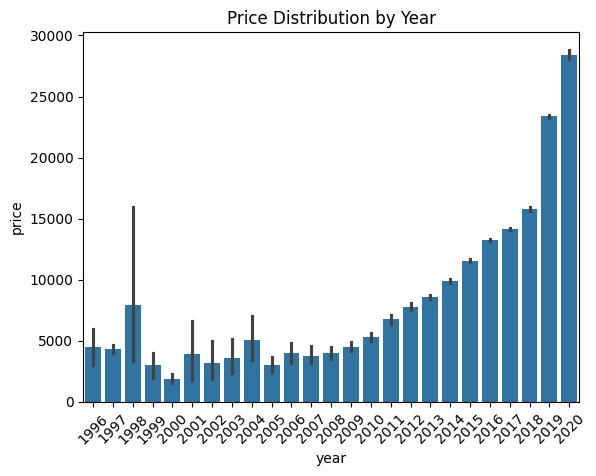

In [11]:
sns.barplot(x='year', y='price', data=df)
plt.title('Price Distribution by Year')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions

## Concluzii
##### In diagrama de mai sus se pune si mai bine in evidenta corelatia dintre an si pret , regula distributiei in diagrama la o prima mana ar fi ca masinile noi sunt mai scumpe decat cele vechi totusi se observa si exceptii , ceea ce duce la ideea anterior mentionata ca pretul unei masini este influentat de mai multi factori si nu doar de cate unul, ca un exemplu relevant pentru claritate as mentiona faptul ca o masina considerata veche , de epoca sau chiar rara poate fi mai scumpa decat o masina mai noua fapt care este pus in evidenta si in diagrama , ex din 1998 este mai scump decat o buna parte din masinile mai noi intarind ideea ca pretul unei masini este influentat de mai multi factori si nu doar de unul singur.

⚙️ 7. Engine Size vs Price
Bigger engines tend to cost more — is it true?

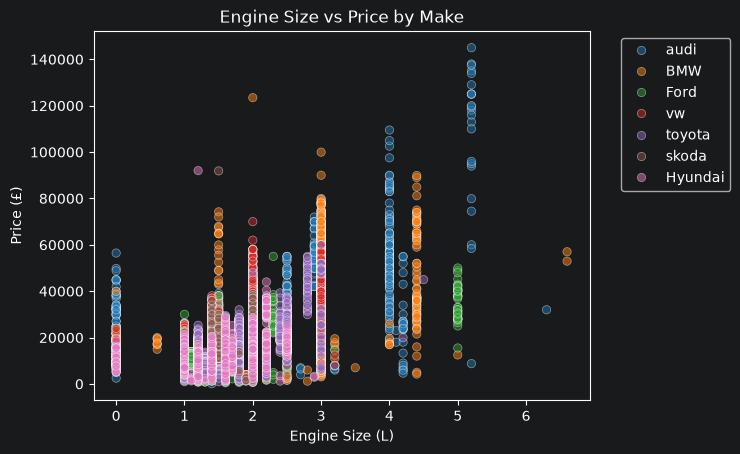

In [12]:
sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5, hue='Make', palette='tab10', legend='full')
plt.title('Engine Size vs Price by Make')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

####  TODO: Write some conclusions

## Concluzii
##### In diagrama de mai sus se pune in evidenta corelatia dintre engine size si pret care este o corelatie slaba avand in vedere ca unele motoare mai mici sunt mai scumpe decat unele motoare mai mari, ca si principiu poate exista o corelatie slaba intre cele doua variabile dar in diagrama se observa din nou faptul ca pretul este influentat de mai multi factori si nu doar de unul de aceea este important sa se ia in considerare mai multi factori atunci cand se doreste o predictie a pretului unei masini . Se poate observa din diagrama ca o ponedere destul de buna o are marca masinii dar totusi nu este suficient de relevanta pentru a face predictii corecte pentru ca dupa cum am observat in diagrama cu marca si modelul masinii si la fel si in asta , marca nu dicteaza neaparat dinamica pretului ci si modelul este un factor important. Ca si concluzie finala a acestei diagrame se poate spune ca exista o corelatie slaba intre engine size si pret dar nu suficient de relevanta luata individual si totodata de aici putem observa si legatura dintre marca masinii si engine size dar intre acestea exista o corelatie destul de slaba pentru ca majoritate marcilor au si masini cu motoare mari si medii dar si mici.

🛣️ 8. MPG vs Price
Fuel efficiency vs cost.

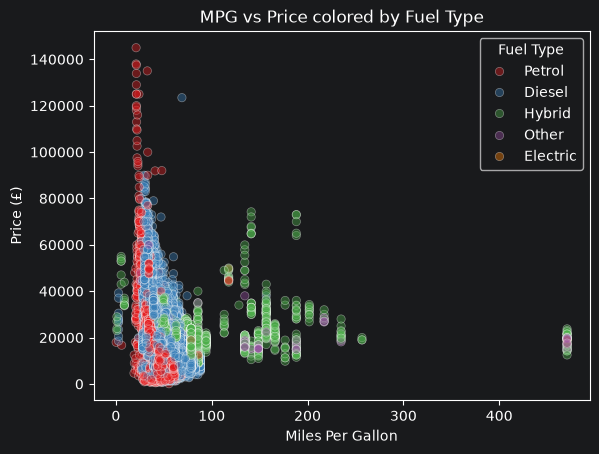

In [13]:
sns.scatterplot(x='mpg', y='price', data=df, alpha=0.4, hue='fuelType', palette='Set1')
plt.title('MPG vs Price colored by Fuel Type')
plt.xlabel('Miles Per Gallon')
plt.ylabel('Price (£)')
plt.legend(title='Fuel Type')
plt.show()

####  TODO: Write some conclusions

## Concluzii
##### Din diagrama se observa o corelatie relativ mai puternica intre tipul de combustibil si consumul masinii decat intre pret si consum. Se observa ca masinile diesel, electrice, hybride si pe benzina sunt in principiu mid range ca pret , chiar low range si ca cele hybride si cele din categoria other au un consum mai mare decat restul categoriilor. Totusi si observa faptul ca masinile pe benzina cu un consum foarte mic sunt cele mai scumpe categorii urmate de cele diesel cu consum mic .

### Let's see how these are correlated to the price

📦 9. Correlation Heatmap
Find linear relationships between numeric features.

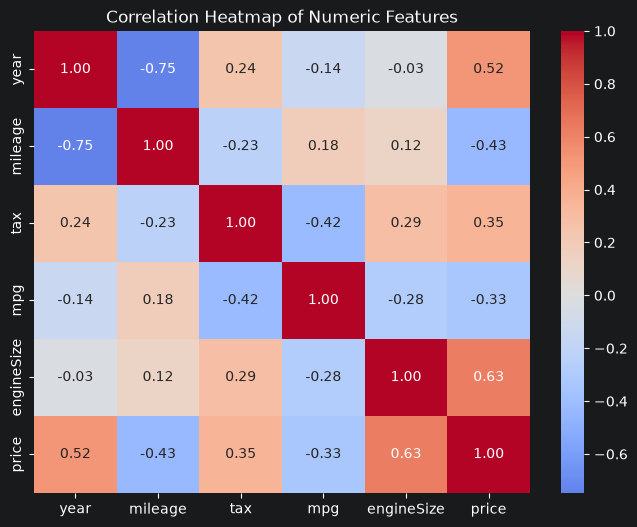

In [14]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [15]:
corr = df.corr(numeric_only=True)


C:\Users\NeagVasileDragos\AppData\Local\Temp\ipykernel_23280\3789713215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


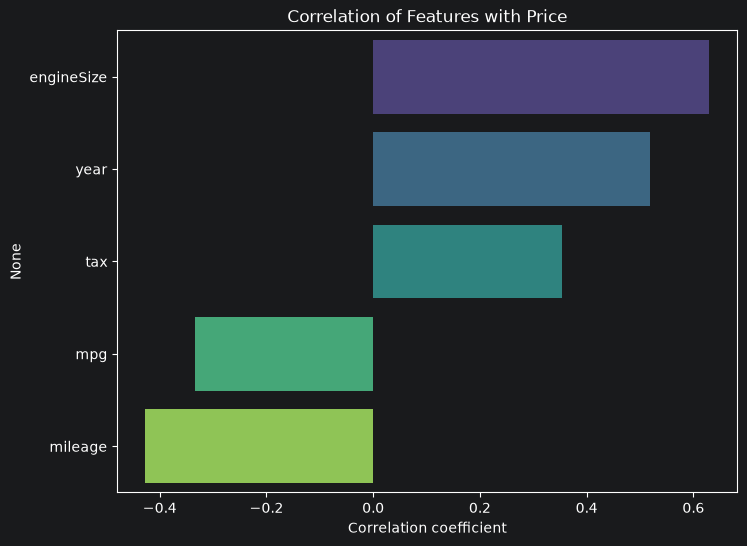

In [16]:

# Correlation with 'price' only
price_corr = corr['price'].sort_values(ascending=False)

# Drop 'price' itself for clarity
price_corr = price_corr.drop('price')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

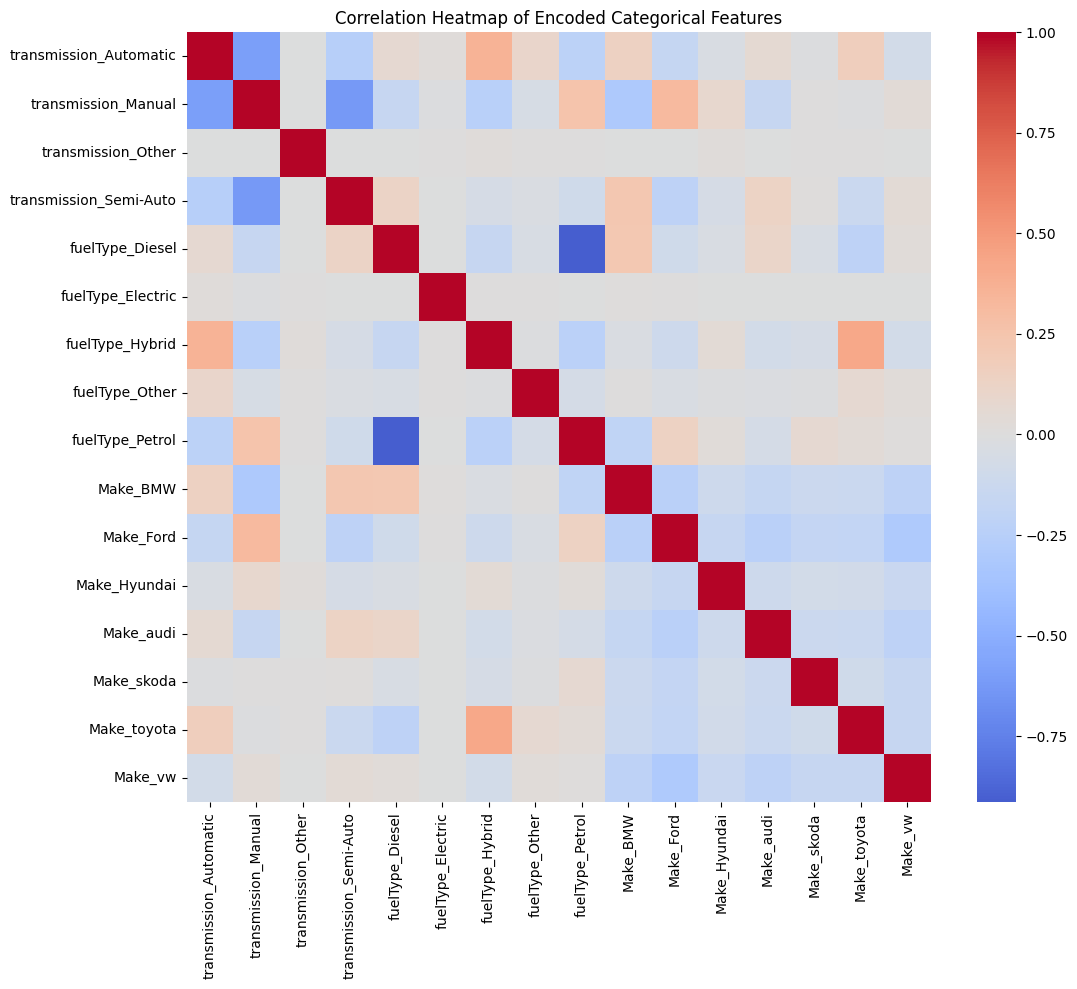

In [17]:
# Drop 'model' and encode categorical columns
df_no_model = df.drop(columns=['model'])
df_encoded = pd.get_dummies(df_no_model, columns=['transmission', 'fuelType', 'Make'])

# Select encoded categorical columns (exclude numeric)
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']
encoded_cols = [col for col in df_encoded.columns if col not in numeric_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[encoded_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Encoded Categorical Features')
plt.show()

#### Ok, we have a lot of correlations here so we can draw a lot of conclusions. When a correlation is approaching to 1, it means that there is a strong correlation between two features, and they are directly proportional to one another. Where the correlation is close to 0, it does not indicate to much for us, no correlation. If the correlation is approaching to -1, it means that there is an inverse proportionality between those features: where one increases, the other one decreaases.

#### TODO: Write at least 10 conclusions based on correlations

### Next steps:
- Feature Engineering: create new or transformed features that may better capture relationships (e.g. : Age of car: car_age = current_year - year, Binning mileage or engineSize into ranges, Log-transform skewed data (e.g., price, mileage), Interactions (e.g., mpg × engineSize))
- Encoding Categorical Features: perfect for transmission, fuelType, Make. Decide what to do with model column (high cardinality column)
- Feature Selection: 
     - You don't always want to keep everything. Good strategies include:
     - Use correlation with price (already done!)
     - SelectKBest, recursive feature elimination (RFE)
     - Model-based importance (e.g., .feature_importances_ from RandomForestRegressor)

#### Let's exemplify these two new features that were engineered based on already existing columns:

In [18]:
import datetime

current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2017,8
1,2016,9
2,2016,9
3,2017,8
4,2019,6


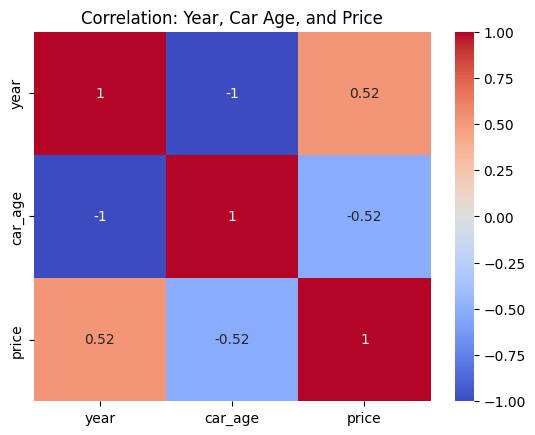

In [19]:
correlation_subset = df[['year', 'car_age', 'price']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year, Car Age, and Price')
plt.show()

#### For example, it did not help. You can work with either car age or year, it gives the same stuff

In [20]:
# Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Check distribution
df['mileage_bin'].value_counts()

mileage_bin
Low          28207
Very Low     23584
Medium       15994
High          4060
Very High      590
Name: count, dtype: int64

#### Create bins for mileage

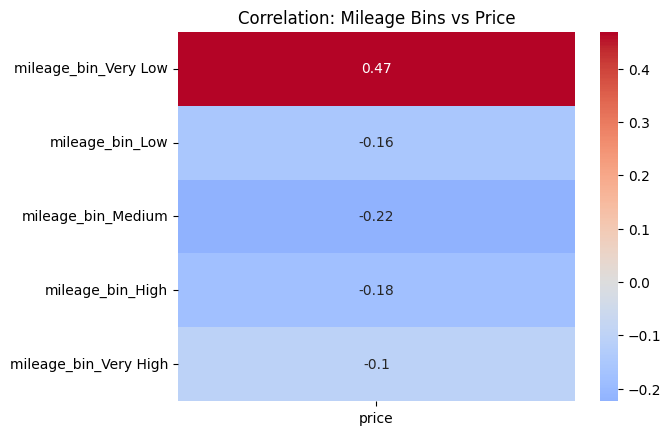

In [21]:
# 1. Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['mileage_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Mileage Bins vs Price')
plt.show()

#### TODO: is it helpful?
-try other ones

#### Let's go back to the dataset, since we have enough information

In [22]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_bin
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,8,Low
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,9,Medium
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,9,Low
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,8,Low
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,6,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0.0,78.4,1.6,Hyundai,9,Low
72431,I40,2015,7830,Manual,59508,Diesel,30.0,65.7,1.7,Hyundai,10,Medium
72432,I10,2017,6830,Manual,13810,Petrol,20.0,60.1,1.0,Hyundai,8,Low
72433,Tucson,2018,13994,Manual,23313,Petrol,145.0,44.8,1.6,Hyundai,7,Low


#### Categorical features need to be endoded

| Column         | Type             | Strategy                       | Notes                                    |
| -------------- | ---------------- | ------------------------------ | ---------------------------------------- |
| `transmission` | Categorical      | One-hot encoding               | Few categories                           |
| `fuelType`     | Categorical      | One-hot encoding               | Few categories                           |
| `Make`         | Categorical      | One-hot encoding               | Moderate number of brands (OK to encode) |
| `model`        | High-cardinality | Exclude or use target encoding | Too many unique values                   |
| `mileage_bin`  | Ordinal-ish      | Ordinal encoding or one-hot    | Low to high — either way works           |


In [23]:
mileage_bin_order = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['mileage_bin_encoded'] = df['mileage_bin'].map(mileage_bin_order)

# Now create df_encoded, drop 'model' and 'mileage_bin' (keep mileage_bin_encoded)
df_encoded = df.drop(columns=['model', 'mileage_bin'])

# One-hot encode categorical variables (except mileage_bin_encoded which is numeric now)
df_encoded = pd.get_dummies(df_encoded, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

In [24]:
df_encoded

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_bin_encoded,transmission_Manual,transmission_Other,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,12500,15735,150.0,55.4,1.4,8,1,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20.0,64.2,2.0,9,2,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30.0,55.4,1.4,9,1,True,False,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145.0,67.3,2.0,8,1,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145.0,49.6,1.0,6,0,True,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0.0,78.4,1.6,9,1,True,False,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30.0,65.7,1.7,10,2,True,False,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20.0,60.1,1.0,8,1,True,False,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145.0,44.8,1.6,7,1,True,False,...,False,False,False,True,False,True,False,False,False,False


#### Feature selection:  I will drop car_age since it is not helpful and also model because it has that huge cardinality

#### We have to decide to use mileage or binned column, mileage_bin_encoded. For now, we will stick to the original column

In [25]:
columns_to_drop = ['model', 'car_age', 'mileage_bin_encoded']  
df_clean = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,12500,15735,150.0,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20.0,64.2,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30.0,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145.0,67.3,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145.0,49.6,1.0,True,False,False,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0.0,78.4,1.6,True,False,False,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30.0,65.7,1.7,True,False,False,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20.0,60.1,1.0,True,False,False,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145.0,44.8,1.6,True,False,False,False,False,False,True,False,True,False,False,False,False


In [26]:
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [27]:
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,12500,15735,150.0,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
1,2016,16500,36203,20.0,64.2,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,2016,11000,29946,30.0,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
3,2017,16800,25952,145.0,67.3,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,2019,17300,1998,145.0,49.6,1.0,1,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0.0,78.4,1.6,1,0,0,0,0,0,0,0,1,0,0,0,0
72431,2015,7830,59508,30.0,65.7,1.7,1,0,0,0,0,0,0,0,1,0,0,0,0
72432,2017,6830,13810,20.0,60.1,1.0,1,0,0,0,0,0,1,0,1,0,0,0,0
72433,2018,13994,23313,145.0,44.8,1.6,1,0,0,0,0,0,1,0,1,0,0,0,0


#### TODO: Consider improvements like Standardization or Normalization:

| Technique           | What it does                            | When to use                                                                                                                                                         |
| ------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Standardization** | Centers data to mean=0, std=1 (z-score) | When features have different units/scales, and your model assumes normality or is sensitive to scale (e.g., linear regression, logistic regression, SVM, k-NN, PCA) |
| **Normalization**   | Scales data to \[0,1] range             | When you want features in same scale but not necessarily centered, often useful for neural networks, distance-based models                                          |


# Next Steps for Your ML Pipeline

### 1. Split data into training and testing sets
- Use `train_test_split` (e.g., 80% train, 20% test) to evaluate your model’s performance on unseen data.

In [28]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((57948, 18), (14487, 18), (57948,), (14487,))


### 2. (Optional) Further feature engineering or selection
- Try feature importance or recursive elimination to reduce noise.
- Experiment with polynomial features or interaction terms if it makes sense.

### 3. Choose machine learning model(s)
- Start simple: Linear Regression, Decision Trees, Random Forest, Gradient Boosting.
- For regression, consider models like:  
  - Linear Regression  
  - RandomForestRegressor  
  - XGBoost / LightGBM  
  - Support Vector Regression (SVR)

In [30]:
# Initialize and train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)


### 4. Cross-validation
- Use K-Fold Cross Validation (e.g., 5 or 10 folds) on training set for robust performance estimation.
- Tune hyperparameters via grid search or random search within CV.

### TODO: perform cross-validation and choose best model! Play with parameters

### 5. Train final model on full training data
- Once hyperparameters are set, train model on all training data.

In [31]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



### 6. Evaluate on test data
- Predict on test set.
- Calculate key metrics like:  
  - MAE (Mean Absolute Error)  
  - RMSE (Root Mean Squared Error)  
  - R² (Coefficient of Determination)


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1321.57
RMSE: 2323.89
R²: 0.939


MAE (Mean Absolute Error) = 1321.57
On average, your model's predicted car prices are off by about $1,322 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 2323.89
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$2,324 means larger errors exist, but overall the predictions are quite close. RMSE is more sensitive to outliers.

R² (Coefficient of Determination) = 0.939
This means your model explains about 93.9% of the variance in car prices. The closer to 1, the better the model fits the data. So 0.939 is excellent — your model predicts prices very well.

### 7. Visualize results
- Plot predicted vs actual prices scatter plot.
- Residual plots to check errors.
- Feature importance plots (for tree-based models).
- Learning curves if needed (to check for overfitting/underfitting).

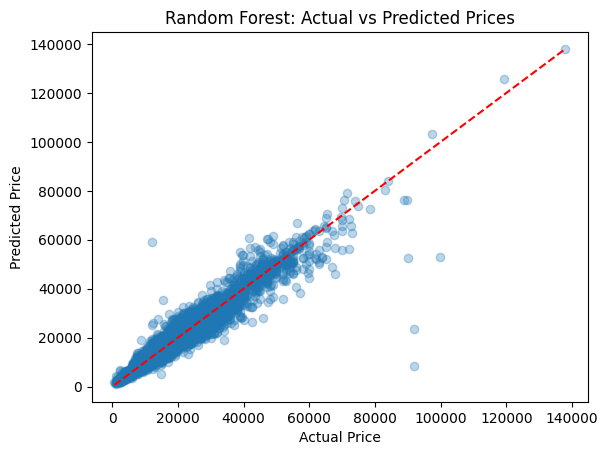

In [33]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#### TODO: How well it fit the regression line?

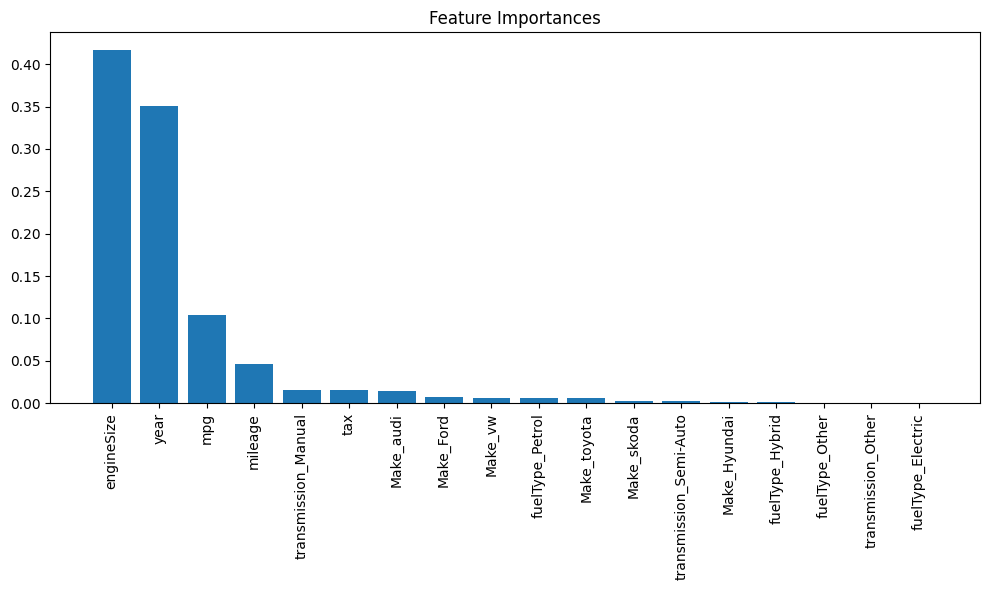

In [34]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()











### 8. Interpret and report
- Summarize model performance.
- Note any limitations or areas for improvement.

### 9. (Optional) Model improvement
- Try more advanced feature engineering.
- Try ensemble methods or stacking.
- Use domain knowledge for custom features.

### 10. Deployment (if needed)
- Prepare pipeline for new data.
- Save model using `joblib` or `pickle`.


## TODO: Find the next notebook here in Regression folder, it contains a dataset about house pricings in the USA. Perform Regression and all the learned techniques on it!!! :) Have fun !